In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import numpy as np

In [68]:
def process_trace(path):
    trace = pd.read_csv(path)
    trace['real_GPU_time'] = 0
    trace['sim_GPU_time'] = 0
    trace['real_CPU_time'] = 0
    trace['sim_CPU_time'] = 0
    trace['real_total_time'] = 0
    trace['sim_total_time'] = 0
    trace['real_batch'] = 0
    trace['sim_batch'] = 0
    return trace

def add_simulated_latencies(path, trace):
    ttft = pd.read_csv(path + '/req_latency.csv')['first_token_latency'].to_numpy()

    assert len(trace) == len(ttft)
    trace['sim_total_time'] = ttft / 1000.0

    batches_df = pd.read_csv(path + '/worker.csv')
    first_decode = batches_df[batches_df['event_type'] == 'do_decode'].index[0]
    batches_df[:first_decode]
    batches_df['prefill_batch_evald'] = batches_df['prefill_batch'].apply(eval)

    index_count_trace = 0
    for i, row in batches_df.iterrows():
        if row['event_type'] == 'do_prefill':
            for j in range(row['prefill_bs']):
                assert trace.iloc[index_count_trace]['input_len'] == row['prefill_batch_evald'][j]
                trace.at[index_count_trace, 'sim_GPU_time'] = row['duration'] / 1000.0
                trace.at[index_count_trace, 'sim_batch'] = str(row['prefill_batch_evald'])
                index_count_trace += 1
    trace['sim_CPU_time'] = trace['sim_total_time'] - trace['sim_GPU_time']
    return trace

def add_real_latencies(path, trace):
    df = pd.read_csv(path)[1:]
    df['time_to_first_tokens_iter_evald'] = df['time_to_first_tokens_iter'].apply(eval)
    df['num_prompt_tokens_reqs_evald'] = df['num_prompt_tokens_reqs'].apply(eval)
    df.loc[:, "step_with_batch_queue_time_ms"] = df["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

    index_count_trace = 0
    diff_count = 0
    for i, row in df.iterrows():
        for j in range(len(row['num_prompt_tokens_reqs_evald'])):
            if trace.iloc[index_count_trace]['input_len'] != row['num_prompt_tokens_reqs_evald'][j]:
                diff_count += 1
                print(f"mismatch at index {index_count_trace}, input_len {trace.iloc[index_count_trace]['input_len']}, num_prompt_tokens_reqs_evald[{j}] {row['num_prompt_tokens_reqs_evald']}")
                trace.at[index_count_trace, 'real_total_time'] = np.nan
                index_count_trace += 1
                continue
            trace.at[index_count_trace, 'real_total_time'] = row['time_to_first_tokens_iter_evald'][j]
            trace.at[index_count_trace, 'real_GPU_time'] = row['step_with_batch_queue_time_ms'] / 1000.0
            trace.at[index_count_trace, 'real_batch'] = str(row['num_prompt_tokens_reqs_evald'])
            index_count_trace += 1
    trace['real_CPU_time'] = trace['real_total_time'] - trace['real_GPU_time']
    print(f"Total mismatches found: {diff_count}")
    return trace


/tmp/ipykernel_283388/1955480279.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.02413626760244369' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  trace.at[index_count_trace, 'sim_GPU_time'] = row['duration'] / 1000.0
/tmp/ipykernel_283388/1955480279.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[34]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  trace.at[index_count_trace, 'sim_batch'] = str(row['prefill_batch_evald'])
/tmp/ipykernel_283388/1955480279.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.028020381927490234' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  trace.at[index_count_trace, 're

mismatch at index 140, input_len 182, num_prompt_tokens_reqs_evald[1] [7, 535, 182]
mismatch at index 141, input_len 535, num_prompt_tokens_reqs_evald[2] [7, 535, 182]
mismatch at index 146, input_len 23, num_prompt_tokens_reqs_evald[0] [660]
mismatch at index 147, input_len 660, num_prompt_tokens_reqs_evald[0] [23, 63, 51]
mismatch at index 218, input_len 128, num_prompt_tokens_reqs_evald[1] [205, 53]
mismatch at index 219, input_len 53, num_prompt_tokens_reqs_evald[0] [128, 192]
mismatch at index 628, input_len 16, num_prompt_tokens_reqs_evald[1] [363, 53, 16]
mismatch at index 629, input_len 53, num_prompt_tokens_reqs_evald[2] [363, 53, 16]
mismatch at index 1159, input_len 15, num_prompt_tokens_reqs_evald[2] [11, 771, 59, 15]
mismatch at index 1160, input_len 59, num_prompt_tokens_reqs_evald[3] [11, 771, 59, 15]
mismatch at index 1292, input_len 9, num_prompt_tokens_reqs_evald[1] [173, 26, 9]
mismatch at index 1293, input_len 26, num_prompt_tokens_reqs_evald[2] [173, 26, 9]
mismatc

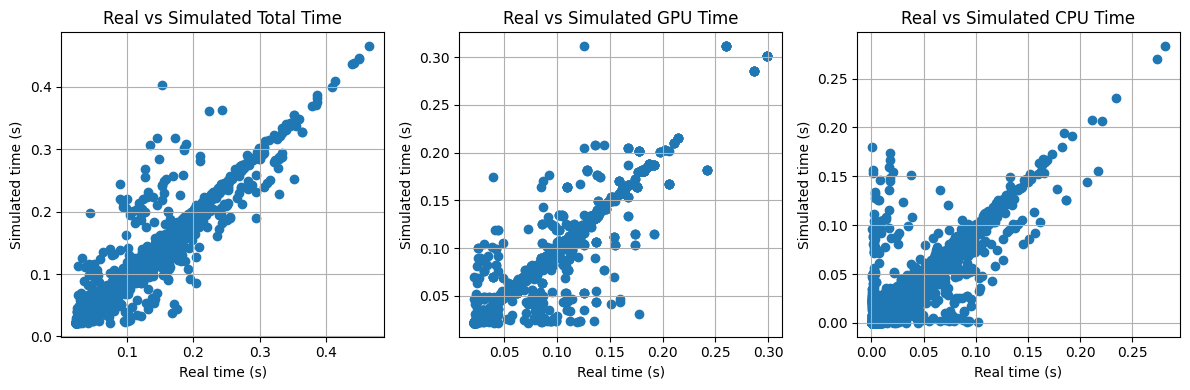

In [69]:
trace = process_trace("/export1/liu3882/llm_energy/DistServe/my_script/new_trace/new_trace_seed1k_n4k_rps22.csv")
trace = add_simulated_latencies("/export1/liu3882/llm_energy/DistServe/my_script/eval_sim_results/tp4/trace_seed1k_n4k_rps22_freq1080/", trace)
trace = add_real_latencies("/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps22_freq1080/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/prefill_0_Oct13040955/engine_0.csv", trace).dropna()

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# Plot total time
axs[0].scatter(trace['real_total_time'], trace['sim_total_time'])
axs[0].set_title('Real vs Simulated Total Time')
axs[0].set_xlabel('Real time (s)')
axs[0].set_ylabel('Simulated time (s)')
axs[0].grid()

# Plot GPU time
axs[1].scatter(trace['real_GPU_time'], trace['sim_GPU_time'])
axs[1].set_title('Real vs Simulated GPU Time')
axs[1].set_xlabel('Real time (s)')
axs[1].set_ylabel('Simulated time (s)')
axs[1].grid()

# Plot CPU time
axs[2].scatter(trace['real_CPU_time'], trace['sim_CPU_time'])
axs[2].set_title('Real vs Simulated CPU Time')
axs[2].set_xlabel('Real time (s)')
axs[2].set_ylabel('Simulated time (s)')
axs[2].grid()

plt.tight_layout()
plt.show()

In [70]:
trace['gpu_perc_error'] = (trace['sim_GPU_time'] - trace['real_GPU_time']).abs() / trace['real_GPU_time'] * 100
trace['cpu_perc_error'] = (trace['sim_CPU_time'] - trace['real_CPU_time']).abs() / trace['real_CPU_time'] * 100
trace['total_perc_error'] = (trace['sim_total_time'] - trace['real_total_time']).abs() / trace['real_total_time'] * 100
trace.to_csv("comparison_results.csv", index=False)

In [71]:
p99_sim_total_time = trace['sim_total_time'].quantile(0.99)
p99_real_total_time = trace['real_total_time'].quantile(0.99)
print(f"P99 sim_total_time: {p99_sim_total_time}")
print(f"P99 real_total_time: {p99_real_total_time}")

P99 sim_total_time: 0.3048399950470587
P99 real_total_time: 0.31692900657653644
